# Recurrent Neural Networks for Time Series Forecasting

This notebook explores the use of **Vanilla RNNs** and **LSTMs** to forecast daily minimum temperatures (TMIN) recorded in New York City's Central Park. The dataset spans more than 150 years of daily observations.

We cover:
1. Exploratory data analysis and autocorrelation structure
2. **Time-based** train / validation / test splitting with no data leakage
3. Univariate forecasting (TMIN only) with a Vanilla RNN and an LSTM
4. Multivariate forecasting using all available weather features
5. Systematic comparison against a trivial **persistence** baseline


## 1. Library and Environment Setup

In [13]:
# Standard library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn (preprocessing only)
from sklearn.preprocessing import MinMaxScaler

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Data Loading and Preprocessing

We load the NYC Central Park weather dataset and perform basic cleaning:
- **Drop `SNWD`** (snow depth): this column has too many missing values to be useful.
- **Parse dates** and set as the DataFrame index for easy time-series operations.
- **Forward-fill** any remaining gaps (rare isolated missing days).

> `weather_df` is treated as read-only from this point on. All transformations that follow operate on separate NumPy arrays so that we can always refer back to the original data.

In [14]:
weather_df = pd.read_csv("NYC_Central_Park_weather_1869-2022.csv")

# SNWD (snow depth) has too many missing values — drop it
weather_df = weather_df.drop(columns=["SNWD"])

# Parse dates and use them as the index
weather_df["DATE"] = pd.to_datetime(weather_df["DATE"])
weather_df.set_index("DATE", inplace=True)

# Forward-fill isolated missing values
weather_df.ffill(inplace=True)

print(f"Shape      : {weather_df.shape}")
print(f"Date range : {weather_df.index[0].date()} → {weather_df.index[-1].date()}")
print(f"Columns    : {list(weather_df.columns)}")
print()
print(weather_df.head())

Shape      : (56245, 4)
Date range : 1869-01-01 → 2022-12-29
Columns    : ['PRCP', 'SNOW', 'TMIN', 'TMAX']

            PRCP  SNOW  TMIN  TMAX
DATE                              
1869-01-01  0.75   9.0  19.0  29.0
1869-01-02  0.03   0.0  21.0  27.0
1869-01-03  0.00   0.0  27.0  35.0
1869-01-04  0.18   0.0  34.0  37.0
1869-01-05  0.05   0.0  37.0  43.0


## 3. Exploratory Data Analysis

Before modelling we inspect:
- **Time series plots** — long-term trends, seasonality, and outliers.
- **Correlation matrix** — linear dependencies between variables (useful for the multivariate section).
- **Autocorrelation of TMIN** — confirms the strong seasonal periodicity (~365 days) that the RNN should learn to exploit.

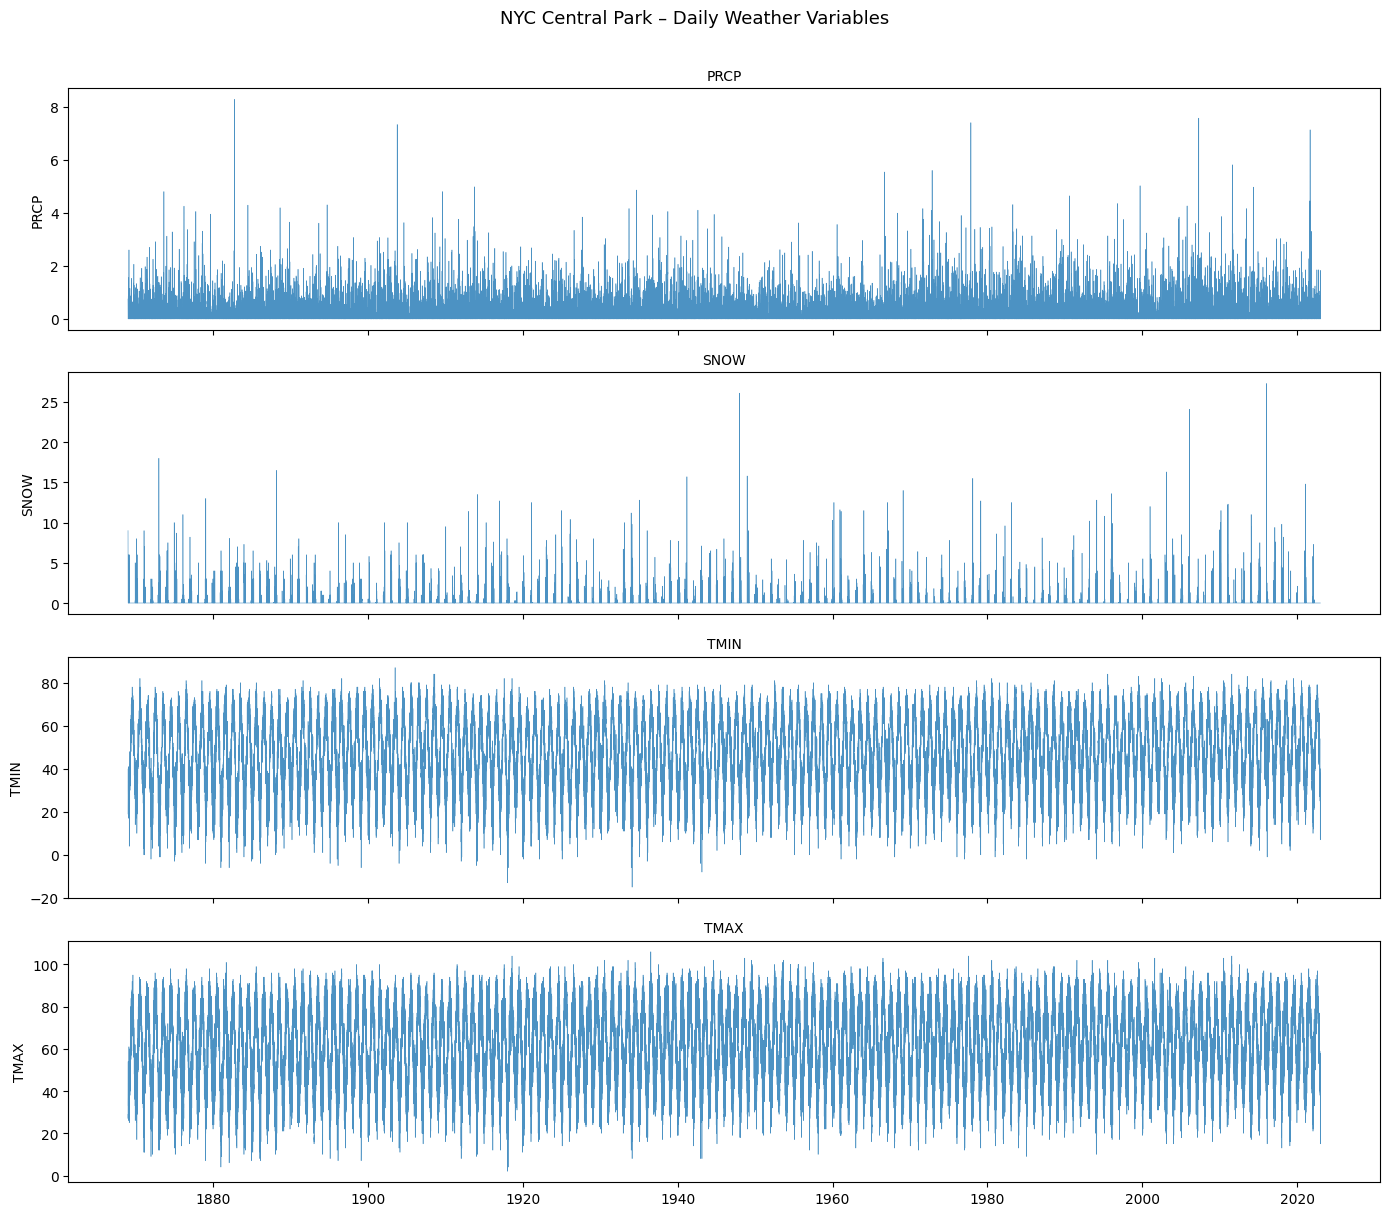

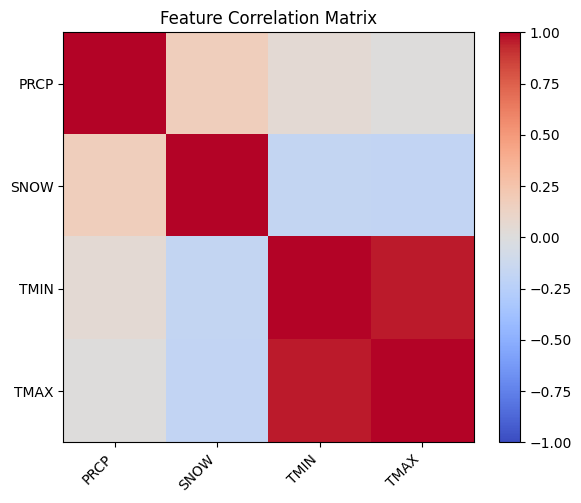

      PRCP  SNOW  TMIN  TMAX
PRCP  1.00  0.17  0.05  0.00
SNOW  0.17  1.00 -0.17 -0.18
TMIN  0.05 -0.17  1.00  0.95
TMAX  0.00 -0.18  0.95  1.00


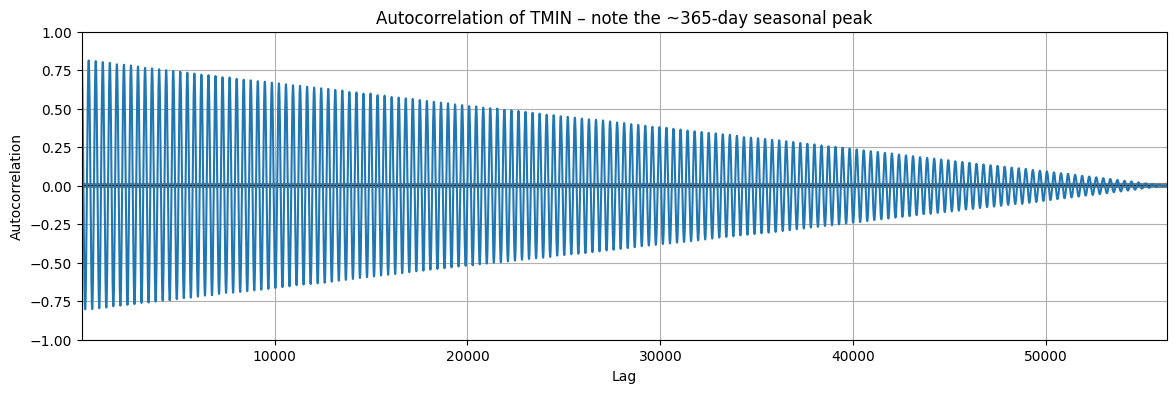

In [15]:
# ── Time series overview ─────────────────────────────────────────────────────
n_cols = len(weather_df.columns)
fig, axes = plt.subplots(n_cols, 1, figsize=(14, 3 * n_cols), sharex=True)
for ax, col in zip(axes, weather_df.columns):
    ax.plot(weather_df.index, weather_df[col], linewidth=0.4, alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel(col)
fig.suptitle("NYC Central Park – Daily Weather Variables", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# ── Correlation matrix ────────────────────────────────────────────────────────
corr = weather_df.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout(); plt.show()
print(corr.round(2))

# ── Autocorrelation of TMIN ───────────────────────────────────────────────────
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(14, 4))
autocorrelation_plot(weather_df["TMIN"])
plt.title("Autocorrelation of TMIN – note the ~365-day seasonal peak")
plt.show()

## 4. Data Preparation

### Why time-based splitting matters
The correct approach is to cut the **raw time series** at fixed time indices first, and then generate sequences independently within each split.

### Scaler fitting
The `MinMaxScaler` must be fitted **only on training data**. Fitting on the full series leaks the global min/max of the validation and test periods into the normalisation, which is a subtle but real form of data leakage.

### Sliding-window sequences
| | |
|---|---|
| **Input** | `input_length` consecutive days (360 ≈ 1 year) |
| **Target** | the following `output_length` days |

Adjust `output_length` freely — the test window will not change.

In [16]:
def create_sequences(data, input_length, output_length):
    """
    Build (input, target) pairs by sliding a window over a 1-D scaled array.

    Parameters
    ----------
    data          : 1-D float32 array of scaled values
    input_length  : number of past steps fed to the model
    output_length : number of future steps to predict

    Returns
    -------
    X : ndarray of shape (N, input_length)
    y : ndarray of shape (N, output_length)
    """
    xs, ys = [], []
    for i in range(len(data) - input_length - output_length + 1):
        xs.append(data[i : i + input_length])
        ys.append(data[i + input_length : i + input_length + output_length])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# ── Forecast horizon ──────────────────────────────────────────────────────────
input_length  = 360  # look-back window (≈ 1 year)
output_length = 1    # forecast horizon — change freely (e.g. 1, 7, 30, 60)
print(f"Input window    : {input_length} days")
print(f"Forecast horizon: {output_length} day(s)")

Input window    : 360 days
Forecast horizon: 1 day(s)


In [17]:
# ── Step 1: extract raw TMIN values — never modify weather_df ────────────────
tmin_values = weather_df["TMIN"].values.copy()   # shape (N,), original units
n = len(tmin_values)

# ── Step 2: time-based split on the raw series ────────────────────────────────
train_end = int(n * 0.70)   # first 70 % → training
val_end   = int(n * 0.85)   # next  15 % → validation  |  last 15 % → test

print(f"Total      : {n:,} days")
print(f"Train  [0 : {train_end}]  →  {train_end:,} days  "
      f"({weather_df.index[0].date()} – {weather_df.index[train_end-1].date()})")
print(f"Val    [{train_end} : {val_end}]  →  {val_end - train_end:,} days  "
      f"({weather_df.index[train_end].date()} – {weather_df.index[val_end-1].date()})")
print(f"Test   [{val_end} : {n}]  →  {n - val_end:,} days  "
      f"({weather_df.index[val_end].date()} – {weather_df.index[-1].date()})")

# ── Step 3: fit scaler on training data only ──────────────────────────────────
scaler = MinMaxScaler()
tmin_train_scaled = scaler.fit_transform(tmin_values[:train_end].reshape(-1, 1)).flatten()
tmin_val_scaled   = scaler.transform(tmin_values[train_end:val_end].reshape(-1, 1)).flatten()
tmin_test_scaled  = scaler.transform(tmin_values[val_end:].reshape(-1, 1)).flatten()

# ── Step 4: create sequences independently within each split ──────────────────
# Sequences never cross split boundaries, so the test window is always
# anchored to the same calendar period regardless of output_length.
X_train, y_train = create_sequences(tmin_train_scaled, input_length, output_length)
X_val,   y_val   = create_sequences(tmin_val_scaled,   input_length, output_length)
X_test,  y_test  = create_sequences(tmin_test_scaled,  input_length, output_length)

print(f"\nSequence shapes  (input_length={input_length}, output_length={output_length}):")
print(f"  X_train: {X_train.shape},  y_train: {y_train.shape}")
print(f"  X_val  : {X_val.shape},  y_val  : {y_val.shape}")
print(f"  X_test : {X_test.shape},  y_test : {y_test.shape}")

Total      : 56,245 days
Train  [0 : 39371]  →  39,371 days  (1869-01-01 – 1976-10-17)
Val    [39371 : 47808]  →  8,437 days  (1976-10-18 – 1999-11-23)
Test   [47808 : 56245]  →  8,437 days  (1999-11-24 – 2022-12-29)

Sequence shapes  (input_length=360, output_length=1):
  X_train: (39011, 360),  y_train: (39011, 1)
  X_val  : (8077, 360),  y_val  : (8077, 1)
  X_test : (8077, 360),  y_test : (8077, 1)


In [18]:
batch_size = 256

def make_loader(X, y, shuffle):
    """
    Wrap (X, y) numpy arrays into a DataLoader.
    Adds a trailing feature dimension to X: (N, seq_len) → (N, seq_len, 1).
    """
    X_t = torch.tensor(X).unsqueeze(-1)  # (N, seq_len, 1)
    y_t = torch.tensor(y)                # (N, output_length)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

## 5. Training Infrastructure

A single `train_model` function is shared by all models in this notebook. It uses:
- **Adam** optimiser
- **MSE** loss (standard for continuous regression)
- **Early stopping**: training halts if the validation loss does not improve for `patience` consecutive epochs, and the best weights are restored

In [19]:
def train_model(model, train_loader, val_loader,
               num_epochs=100, patience=10, lr=1e-4):
    """
    Train `model` with Adam + MSE and early stopping.

    Returns the model loaded with its best weights, plus the per-epoch
    training and validation loss histories.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss     = float("inf")
    epochs_no_improve = 0
    best_weights      = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        # ── Training pass ─────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # ── Validation pass ───────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"train: {train_loss:.5f} | val: {val_loss:.5f}")

        # ── Early stopping ────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            epochs_no_improve = 0
            best_weights      = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_weights)
    return model, train_losses, val_losses


def plot_losses(train_losses, val_losses, title="Loss"):
    plt.figure(figsize=(9, 4))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses,   label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title(title); plt.legend(); plt.grid(True)
    plt.show()

## 6. Vanilla RNN

A two-layer RNN with 100 hidden units per layer. After the recurrent layers, only the **last time step's hidden state** is passed to a linear layer to produce the multi-step forecast.

> **Limitation**: vanilla RNNs can suffer from vanishing/exploding gradients over long input sequences (here 360 steps). We include it as a pedagogical baseline before moving to the LSTM in Section 7.

In [20]:
class RNNModel(nn.Module):
    """
    Stacked Vanilla RNN for multi-step time-series forecasting.

    Forward pass:
        x  (batch, seq_len, input_size)
        → RNN hidden states  (batch, seq_len, hidden_size)
        → last hidden state  (batch, hidden_size)
        → Linear             (batch, output_size)
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.rnn(x, h0)       # (batch, seq_len, hidden_size)
        return self.fc(out[:, -1, :])  # decode last step → (batch, output_size)


rnn_model = RNNModel(
    input_size  = 1,
    hidden_size = 100,
    num_layers  = 2,
    output_size = output_length,
).to(device)

print(rnn_model)
n_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

RNNModel(
  (rnn): RNN(1, 100, num_layers=2, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)

Trainable parameters: 30,601


Epoch   1/20 | train: 0.05072 | val: 0.01497
Epoch   2/20 | train: 0.00804 | val: 0.00479
Epoch   3/20 | train: 0.00493 | val: 0.00464
Epoch   4/20 | train: 0.00478 | val: 0.00447
Epoch   5/20 | train: 0.00461 | val: 0.00430
Epoch   6/20 | train: 0.00444 | val: 0.00418
Epoch   7/20 | train: 0.00426 | val: 0.00395
Epoch   8/20 | train: 0.00410 | val: 0.00379
Epoch   9/20 | train: 0.00394 | val: 0.00371
Epoch  10/20 | train: 0.00379 | val: 0.00351
Epoch  11/20 | train: 0.00364 | val: 0.00336
Epoch  12/20 | train: 0.00350 | val: 0.00327
Epoch  13/20 | train: 0.00341 | val: 0.00312
Epoch  14/20 | train: 0.00328 | val: 0.00308
Epoch  15/20 | train: 0.00318 | val: 0.00293
Epoch  16/20 | train: 0.00309 | val: 0.00287
Epoch  17/20 | train: 0.00299 | val: 0.00279
Epoch  18/20 | train: 0.00294 | val: 0.00273
Epoch  19/20 | train: 0.00289 | val: 0.00270
Epoch  20/20 | train: 0.00285 | val: 0.00266


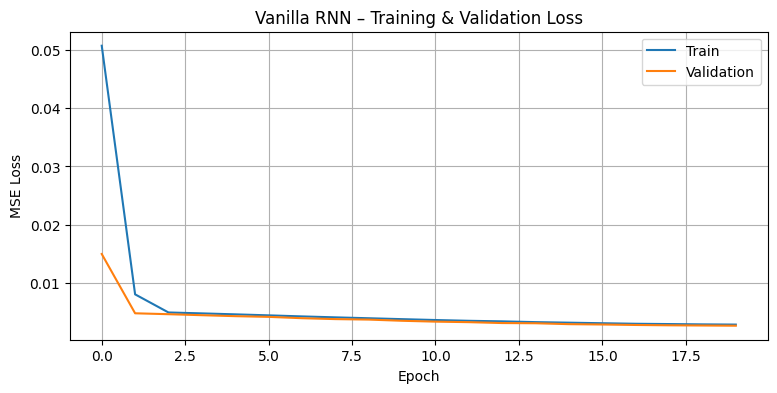

In [21]:
trained_rnn, rnn_train_losses, rnn_val_losses = train_model(
    rnn_model, train_loader, val_loader,
    num_epochs=20, patience=5, lr=1e-4,
)
plot_losses(rnn_train_losses, rnn_val_losses, title="Vanilla RNN – Training & Validation Loss")

## 7. Evaluation

### Trivial (persistence) baseline
The simplest possible predictor repeats the **last observed value** for every future step:

$$\hat{T}_{t+k} = T_t \quad \forall\, k = 1, \ldots, H$$

This is a surprisingly strong baseline for short horizons because temperature is highly autocorrelated. Any learned model should comfortably beat it.

Note that the baseline prediction for step $k=1$ (the very next day) is **identical regardless of the forecast horizon $H$** — it always equals the last input value. This is why the trivial predictor is horizon-agnostic at `forecast_day_index = 0`.

### Metrics
| Metric | Description |
|--------|-------------|
| MAE | Mean Absolute Error — same units as temperature |
| RMSE | Root Mean Squared Error — penalises large errors more heavily |
| MAPE | Mean Absolute Percentage Error — scale-free, sensitive to values near zero |

### `forecast_day_index`
For a multi-step forecast we can evaluate any single horizon step. `0` is the first day ahead, `output_length - 1` is the last.

In [22]:
def evaluate_model(trained_model, X_test, y_test, scaler, output_length,
                   forecast_day_index=0, model_label="Model"):
    """
    Evaluate a trained univariate model on the test set.

    The trivial (persistence) baseline predicts the last observed value
    for every forecast step, so it is horizon-agnostic: its error at
    forecast_day_index=0 is the same whether output_length is 1 or 60.

    Parameters
    ----------
    trained_model      : trained PyTorch model
    X_test, y_test     : (N, input_length) and (N, output_length) float32 arrays
    scaler             : MinMaxScaler fitted on training TMIN only
    output_length      : forecast horizon
    forecast_day_index : step to evaluate, in [0, output_length-1]
    model_label        : string used in prints and plot title
    """
    assert 0 <= forecast_day_index < output_length, (
        f"forecast_day_index must be in [0, {output_length - 1}]"
    )

    # ── Collect predictions ───────────────────────────────────────────────────
    loader = make_loader(X_test, y_test, shuffle=False)
    trained_model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds_list.append(trained_model(X_batch.to(device)).cpu().numpy())
            targets_list.append(y_batch.numpy())

    preds   = np.concatenate(preds_list,   axis=0)  # (N, output_length)
    targets = np.concatenate(targets_list, axis=0)  # (N, output_length)

    # ── Inverse-transform: scaler expects (N, 1) ─────────────────────────────
    # Broadcasting over output_length columns is correct here because every
    # column contains the same TMIN feature.
    preds_inv   = scaler.inverse_transform(preds)    # (N, output_length)
    targets_inv = scaler.inverse_transform(targets)  # (N, output_length)

    # ── Trivial (persistence) baseline ───────────────────────────────────────
    # The last value of each input window is the most recent observation.
    # We inverse-transform it once (correct shape) and tile across the horizon.
    last_obs_scaled = X_test[:, -1:]                              # (N, 1)
    last_obs_inv    = scaler.inverse_transform(last_obs_scaled)   # (N, 1)
    trivial         = np.repeat(last_obs_inv, output_length, axis=1)  # (N, output_length)

    # ── Select the evaluation day ─────────────────────────────────────────────
    p = preds_inv[:, forecast_day_index]
    t = targets_inv[:, forecast_day_index]
    b = trivial[:, forecast_day_index]   # equals last_obs_inv[:, 0] for every index

    # ── Metrics ───────────────────────────────────────────────────────────────
    def metrics(y_true, y_pred):
        mae  = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
        return mae, rmse, mape

    mae_m,  rmse_m,  mape_m  = metrics(t, p)
    mae_b,  rmse_b,  mape_b  = metrics(t, b)

    header = f"Evaluating '{model_label}' — forecast day {forecast_day_index + 1} of {output_length}"
    print(header)
    print("-" * len(header))
    print(f"{'Model':30s}  {'MAE':>8}  {'RMSE':>8}  {'MAPE':>8}")
    print(f"{model_label:30s}  {mae_m:8.4f}  {rmse_m:8.4f}  {mape_m:7.2f}%")
    print(f"{'Trivial (persistence)':30s}  {mae_b:8.4f}  {rmse_b:8.4f}  {mape_b:7.2f}%")

    # ── Plot ──────────────────────────────────────────────────────────────────
    plt.figure(figsize=(14, 5))
    plt.plot(t, label="Actual",       linewidth=0.8)
    plt.plot(p, label=model_label,    linestyle="--", linewidth=0.8)
    plt.plot(b, label="Trivial",      linestyle=":",  linewidth=0.8)
    plt.title(f"{model_label} — Day {forecast_day_index + 1} of {output_length}-step horizon")
    plt.xlabel("Test sample index"); plt.ylabel("TMIN")
    plt.legend(); plt.grid(True)
    plt.show()

    return preds_inv, targets_inv, trivial

Evaluating 'Vanilla RNN' — forecast day 1 of 1
----------------------------------------------
Model                                MAE      RMSE      MAPE
Vanilla RNN                       3.9735    5.1585    11.34%
Trivial (persistence)             4.1486    5.5309    11.36%


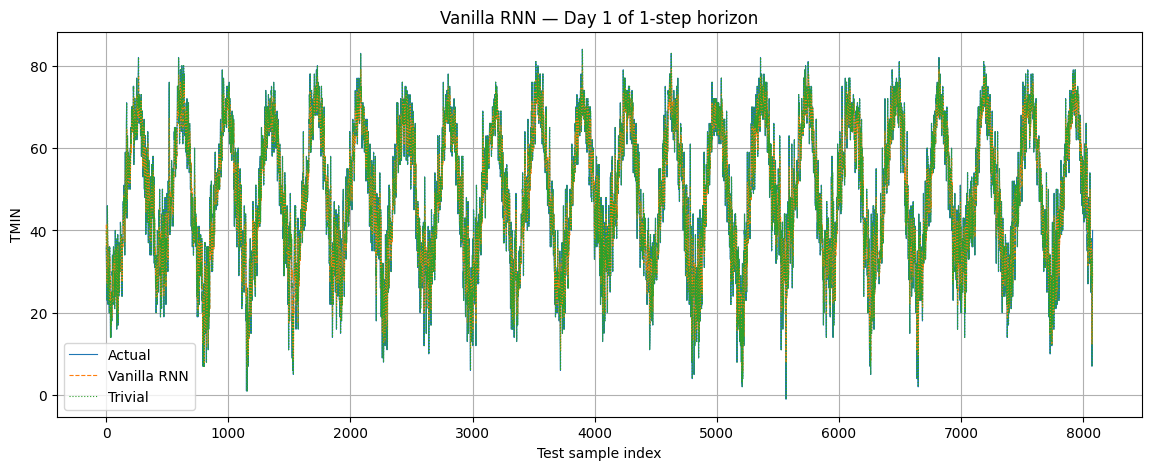

In [23]:
# Evaluate the RNN on the first forecast day (day+1 ahead).
# Setting forecast_day_index=0 means we compare:
#   - model output[:, 0]  → predicted TMIN for the very next day
#   - trivial[:, 0]       → last observed TMIN (persistence)
# Both sides use the same target, so the comparison is fair.
rnn_preds, rnn_targets, rnn_trivial = evaluate_model(
    trained_rnn, X_test, y_test, scaler,
    output_length      = output_length,
    forecast_day_index = 0,
    model_label        = "Vanilla RNN",
)

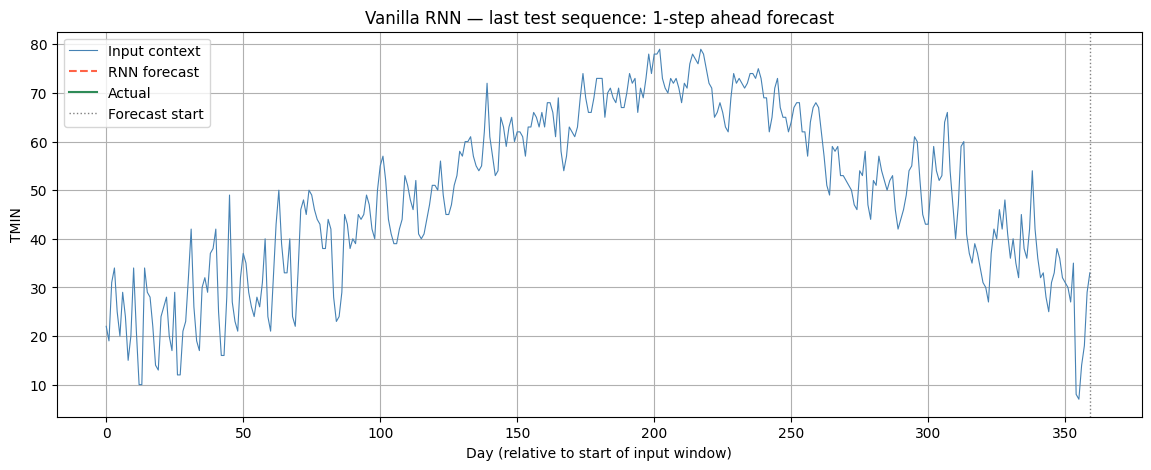

In [24]:
# ── Detailed look at the final test sequence ─────────────────────────────────
# We feed the last input window of the test set through the model and
# compare its full multi-step forecast against the true future values.

trained_rnn.eval()
with torch.no_grad():
    last_input_t = torch.tensor(X_test[-1:]).unsqueeze(-1).to(device)  # (1, 360, 1)
    last_pred_scaled = trained_rnn(last_input_t).cpu().numpy()[0]      # (output_length,)

# Inverse-transform each component individually (clean shape management)
last_input_inv = scaler.inverse_transform(X_test[-1].reshape(-1, 1)).flatten()   # (input_length,)
last_pred_inv  = scaler.inverse_transform(last_pred_scaled.reshape(-1, 1)).flatten()  # (output_length,)
last_true_inv  = scaler.inverse_transform(y_test[-1].reshape(-1, 1)).flatten()        # (output_length,)

x_input    = np.arange(input_length)
x_forecast = np.arange(input_length, input_length + output_length)

plt.figure(figsize=(14, 5))
plt.plot(x_input,    last_input_inv, label="Input context",  color="steelblue", linewidth=0.8)
plt.plot(x_forecast, last_pred_inv,  label="RNN forecast",   color="tomato",    linestyle="--", linewidth=1.5)
plt.plot(x_forecast, last_true_inv,  label="Actual",         color="seagreen",  linewidth=1.5)
plt.axvline(input_length - 1, color="gray", linestyle=":", linewidth=1, label="Forecast start")
plt.title(f"Vanilla RNN — last test sequence: {output_length}-step ahead forecast")
plt.xlabel("Day (relative to start of input window)"); plt.ylabel("TMIN")
plt.legend(); plt.grid(True)
plt.show()

## 8. LSTM

The **Long Short-Term Memory** network addresses the vanishing gradient problem through its three gating mechanisms (input, forget, output gates) and an explicit **cell state** that can carry information across many time steps.

The architecture here mirrors the RNN but adds:
- A cell state `c₀` initialised to zeros alongside the hidden state `h₀`.
- Dropout applied **between** LSTM layers (set to 0 when `num_layers=1` to avoid a PyTorch warning).

We expect the LSTM to perform at least as well as the vanilla RNN, especially for longer forecast horizons where long-range dependencies matter more.

In [25]:
class LSTMModel(nn.Module):
    """
    Stacked LSTM for multi-step time-series forecasting.

    Forward pass:
        x  (batch, seq_len, input_size)
        → LSTM hidden/cell states  (batch, seq_len, hidden_size)
        → last hidden state        (batch, hidden_size)
        → Linear                   (batch, output_size)
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        # dropout is only applied between layers; disable it for single-layer models
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))  # (batch, seq_len, hidden_size)
        return self.fc(out[:, -1, :])    # decode last step → (batch, output_size)


lstm_model = LSTMModel(
    input_size  = 1,
    hidden_size = 100,
    num_layers  = 2,
    output_size = output_length,
    dropout     = 0.3,
).to(device)

print(lstm_model)
n_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

LSTMModel(
  (lstm): LSTM(1, 100, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)

Trainable parameters: 122,101


Epoch   1/20 | train: 0.02089 | val: 0.00512
Epoch   2/20 | train: 0.00558 | val: 0.00540
Epoch   3/20 | train: 0.00540 | val: 0.00477
Epoch   4/20 | train: 0.00519 | val: 0.00458
Epoch   5/20 | train: 0.00495 | val: 0.00433
Epoch   6/20 | train: 0.00457 | val: 0.00389
Epoch   7/20 | train: 0.00401 | val: 0.00332
Epoch   8/20 | train: 0.00338 | val: 0.00274
Epoch   9/20 | train: 0.00316 | val: 0.00289
Epoch  10/20 | train: 0.00313 | val: 0.00264
Epoch  11/20 | train: 0.00301 | val: 0.00270
Epoch  12/20 | train: 0.00305 | val: 0.00271
Epoch  13/20 | train: 0.00297 | val: 0.00271
Epoch  14/20 | train: 0.00294 | val: 0.00274
Epoch  15/20 | train: 0.00295 | val: 0.00261
Epoch  16/20 | train: 0.00291 | val: 0.00266
Epoch  17/20 | train: 0.00293 | val: 0.00262
Epoch  18/20 | train: 0.00289 | val: 0.00263
Epoch  19/20 | train: 0.00289 | val: 0.00263
Epoch  20/20 | train: 0.00290 | val: 0.00264
Early stopping at epoch 20.


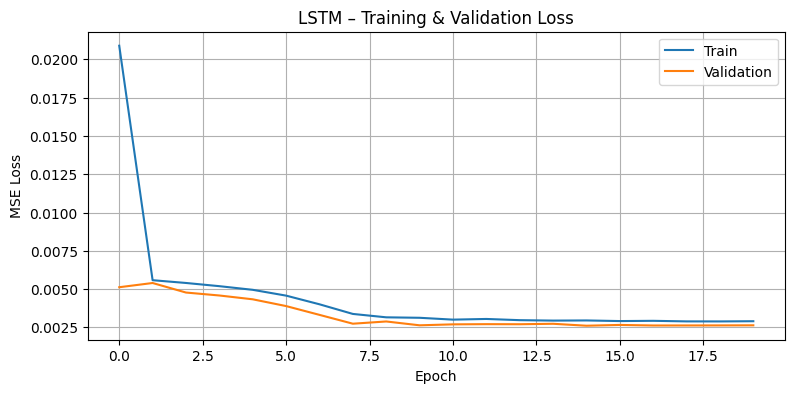

Evaluating 'LSTM' — forecast day 1 of 1
---------------------------------------
Model                                MAE      RMSE      MAPE
LSTM                              3.9141    5.1013    11.49%
Trivial (persistence)             4.1486    5.5309    11.36%


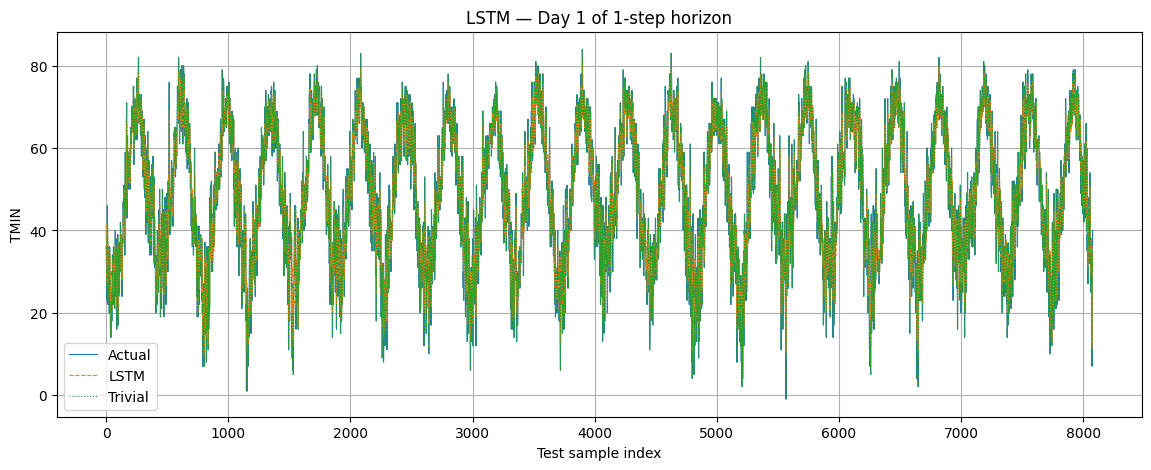

In [26]:
trained_lstm, lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, train_loader, val_loader,
    num_epochs=20, patience=5, lr=1e-3,
)
plot_losses(lstm_train_losses, lstm_val_losses, title="LSTM – Training & Validation Loss")

lstm_preds, lstm_targets, lstm_trivial = evaluate_model(
    trained_lstm, X_test, y_test, scaler,
    output_length      = output_length,
    forecast_day_index = 0,
    model_label        = "LSTM",
)

## 9. Multivariate RNN

So far the model used only TMIN as input. Here we use **all available features** (PRCP, SNOW, TMAX, TMIN) as inputs while still predicting TMIN only.

### Inverse-transform in the multivariate setting
The multivariate `MinMaxScaler` has a **different min/max for each feature**. To invert only the TMIN predictions we must:
1. Place the scaled predictions in a zero-padded array at the correct **TMIN column index**.
2. Apply `inverse_transform` on the padded array.
3. Extract the TMIN column from the result.

The TMIN column index is looked up dynamically from `weather_df.columns` rather than being hardcoded.

In [27]:
# ── Work on a clean copy of the data — never touch weather_df ────────────────
all_features  = weather_df.values.copy()          # (N, n_features), original scale
feature_names = list(weather_df.columns)
n_features    = len(feature_names)
tmin_col      = feature_names.index("TMIN")       # locate TMIN column dynamically

print(f"Features ({n_features}): {feature_names}")
print(f"TMIN is at column index : {tmin_col}")

# ── Time-based split (same boundaries as the univariate section) ──────────────
n_multi     = len(all_features)
train_end_m = int(n_multi * 0.70)
val_end_m   = int(n_multi * 0.85)

# ── Fit the multivariate scaler on training data only ────────────────────────
multi_scaler = MinMaxScaler()
train_scaled_m = multi_scaler.fit_transform(all_features[:train_end_m])
val_scaled_m   = multi_scaler.transform(all_features[train_end_m:val_end_m])
test_scaled_m  = multi_scaler.transform(all_features[val_end_m:])


def create_sequences_multi(data, input_length, output_length, target_col):
    """
    Sliding-window sequence builder for multivariate input / univariate output.

    Parameters
    ----------
    data        : (T, n_features) scaled array
    target_col  : column index of the variable to predict
    """
    xs, ys = [], []
    for i in range(len(data) - input_length - output_length + 1):
        xs.append(data[i : i + input_length])                               # (input_length, n_features)
        ys.append(data[i + input_length : i + input_length + output_length, target_col])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)


X_train_m, y_train_m = create_sequences_multi(train_scaled_m, input_length, output_length, tmin_col)
X_val_m,   y_val_m   = create_sequences_multi(val_scaled_m,   input_length, output_length, tmin_col)
X_test_m,  y_test_m  = create_sequences_multi(test_scaled_m,  input_length, output_length, tmin_col)

print(f"\nX_train_m: {X_train_m.shape}   y_train_m: {y_train_m.shape}")
print(f"X_val_m  : {X_val_m.shape}   y_val_m  : {y_val_m.shape}")
print(f"X_test_m : {X_test_m.shape}   y_test_m : {y_test_m.shape}")

# DataLoaders: X already has the feature dimension — no unsqueeze needed
def make_loader_multi(X, y, shuffle):
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y)),
        batch_size=batch_size, shuffle=shuffle,
    )

train_loader_m = make_loader_multi(X_train_m, y_train_m, shuffle=True)
val_loader_m   = make_loader_multi(X_val_m,   y_val_m,   shuffle=False)
test_loader_m  = make_loader_multi(X_test_m,  y_test_m,  shuffle=False)

Features (4): ['PRCP', 'SNOW', 'TMIN', 'TMAX']
TMIN is at column index : 2

X_train_m: (39011, 360, 4)   y_train_m: (39011, 1)
X_val_m  : (8077, 360, 4)   y_val_m  : (8077, 1)
X_test_m : (8077, 360, 4)   y_test_m : (8077, 1)


RNNModel(
  (rnn): RNN(4, 500, num_layers=2, batch_first=True)
  (fc): Linear(in_features=500, out_features=1, bias=True)
)

Trainable parameters: 754,501
Epoch   1/20 | train: 0.01838 | val: 0.00399
Epoch   2/20 | train: 0.00391 | val: 0.00340
Epoch   3/20 | train: 0.00343 | val: 0.00305
Epoch   4/20 | train: 0.00309 | val: 0.00281
Epoch   5/20 | train: 0.00290 | val: 0.00279
Epoch   6/20 | train: 0.00281 | val: 0.00267
Epoch   7/20 | train: 0.00273 | val: 0.00252
Epoch   8/20 | train: 0.00272 | val: 0.00250
Epoch   9/20 | train: 0.00266 | val: 0.00248
Epoch  10/20 | train: 0.00265 | val: 0.00249
Epoch  11/20 | train: 0.00265 | val: 0.00245
Epoch  12/20 | train: 0.00264 | val: 0.00249
Epoch  13/20 | train: 0.00264 | val: 0.00253
Epoch  14/20 | train: 0.00266 | val: 0.00272
Epoch  15/20 | train: 0.00266 | val: 0.00246
Epoch  16/20 | train: 0.00266 | val: 0.00255
Early stopping at epoch 16.


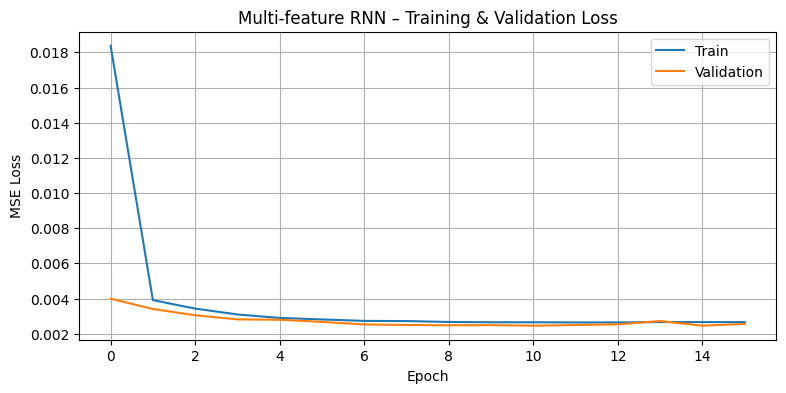

In [28]:
multi_rnn = RNNModel(
    input_size  = n_features,
    hidden_size = 500,
    num_layers  = 2,
    output_size = output_length,
).to(device)

print(multi_rnn)
n_params = sum(p.numel() for p in multi_rnn.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

trained_multi_rnn, multi_train_losses, multi_val_losses = train_model(
    multi_rnn, train_loader_m, val_loader_m,
    num_epochs=20, patience=5, lr=1e-4,
)
plot_losses(multi_train_losses, multi_val_losses,
            title="Multi-feature RNN – Training & Validation Loss")

Multi-feature RNN — forecast day 1 of 1
---------------------------------------
Model                                MAE      RMSE      MAPE
Multi-feature RNN                 3.8086    4.9421    11.01%
Trivial (persistence)             4.1486    5.5309    11.36%


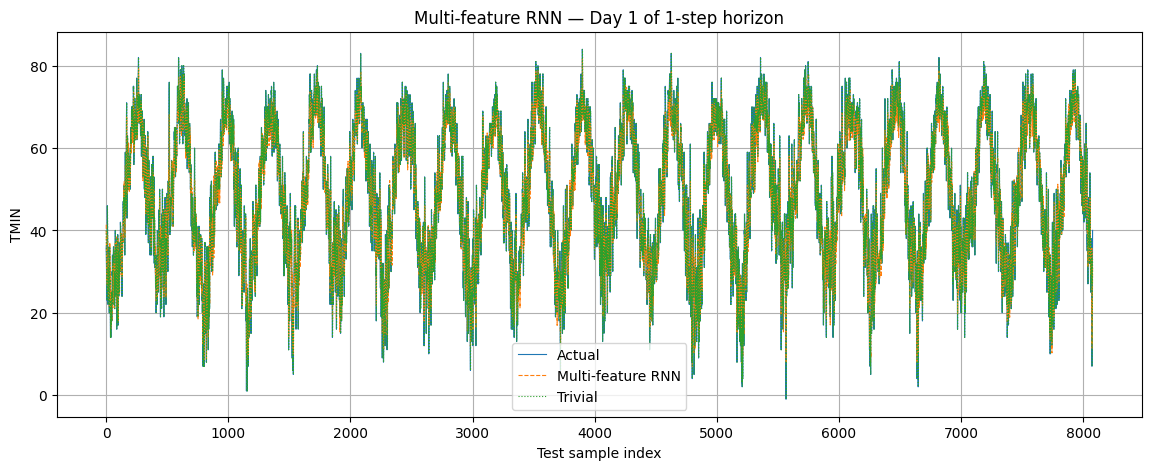

In [29]:
# ── Choose which forecast day to evaluate ────────────────────────────────────
forecast_day_index_m = 0   # 0 = next day, output_length-1 = last step

# ── Collect test predictions ──────────────────────────────────────────────────
trained_multi_rnn.eval()
preds_m_list, targets_m_list = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_m:
        preds_m_list.append(trained_multi_rnn(X_batch.to(device)).cpu().numpy())
        targets_m_list.append(y_batch.numpy())

preds_m   = np.concatenate(preds_m_list,   axis=0)  # (N, output_length) — scaled TMIN
targets_m = np.concatenate(targets_m_list, axis=0)  # (N, output_length) — scaled TMIN

# ── Inverse-transform TMIN only ───────────────────────────────────────────────
# The multivariate scaler has different parameters per feature, so we must
# insert the scaled TMIN values into the correct column of a zero-padded array
# before calling inverse_transform, then extract that column afterward.
def inv_tmin_multi(scaled_cols, multi_scaler, tmin_col, n_features):
    """
    Inverse-transform an (N, K) array of scaled TMIN values using the
    multivariate scaler. Returns an (N, K) array in original TMIN units.
    """
    scaled_cols = np.atleast_2d(scaled_cols)
    N, K = scaled_cols.shape
    result = np.empty_like(scaled_cols)
    for k in range(K):
        pad = np.zeros((N, n_features))
        pad[:, tmin_col] = scaled_cols[:, k]
        result[:, k] = multi_scaler.inverse_transform(pad)[:, tmin_col]
    return result

preds_m_inv   = inv_tmin_multi(preds_m,   multi_scaler, tmin_col, n_features)
targets_m_inv = inv_tmin_multi(targets_m, multi_scaler, tmin_col, n_features)

# ── Trivial (persistence) baseline ────────────────────────────────────────────
# Last TMIN value in each input window (X_test_m has shape (N, input_length, n_features))
last_tmin_scaled = X_test_m[:, -1, tmin_col].reshape(-1, 1)   # (N, 1)
last_tmin_inv    = inv_tmin_multi(last_tmin_scaled, multi_scaler, tmin_col, n_features)  # (N, 1)
trivial_m        = np.repeat(last_tmin_inv, output_length, axis=1)  # (N, output_length)

# ── Select the evaluation day and compute metrics ─────────────────────────────
p_m = preds_m_inv[:, forecast_day_index_m]
t_m = targets_m_inv[:, forecast_day_index_m]
b_m = trivial_m[:, forecast_day_index_m]

def metrics(y_true, y_pred):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

mae_m,  rmse_m,  mape_m  = metrics(t_m, p_m)
mae_b,  rmse_b,  mape_b  = metrics(t_m, b_m)

header = (f"Multi-feature RNN — forecast day "
          f"{forecast_day_index_m + 1} of {output_length}")
print(header)
print("-" * len(header))
print(f"{'Model':30s}  {'MAE':>8}  {'RMSE':>8}  {'MAPE':>8}")
print(f"{'Multi-feature RNN':30s}  {mae_m:8.4f}  {rmse_m:8.4f}  {mape_m:7.2f}%")
print(f"{'Trivial (persistence)':30s}  {mae_b:8.4f}  {rmse_b:8.4f}  {mape_b:7.2f}%")

plt.figure(figsize=(14, 5))
plt.plot(t_m, label="Actual",           linewidth=0.8)
plt.plot(p_m, label="Multi-feature RNN",linestyle="--", linewidth=0.8)
plt.plot(b_m, label="Trivial",          linestyle=":",  linewidth=0.8)
plt.title(f"Multi-feature RNN — Day {forecast_day_index_m + 1} of {output_length}-step horizon")
plt.xlabel("Test sample index"); plt.ylabel("TMIN")
plt.legend(); plt.grid(True)
plt.show()